In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


In [4]:
train_data = pd.read_csv(r"C:\Users\rohit\OneDrive\Desktop\mach_learning\Titanic_Disaster_pred\Titanic_data\train.csv")
test_data = pd.read_csv(r"C:\Users\rohit\OneDrive\Desktop\mach_learning\Titanic_Disaster_pred\Titanic_data\test.csv")

In [5]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

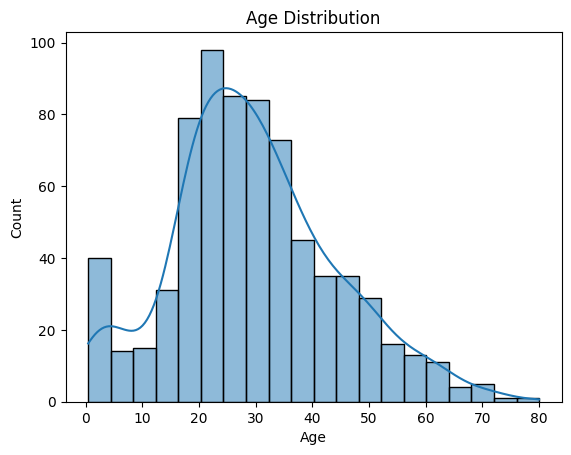

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train_data["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


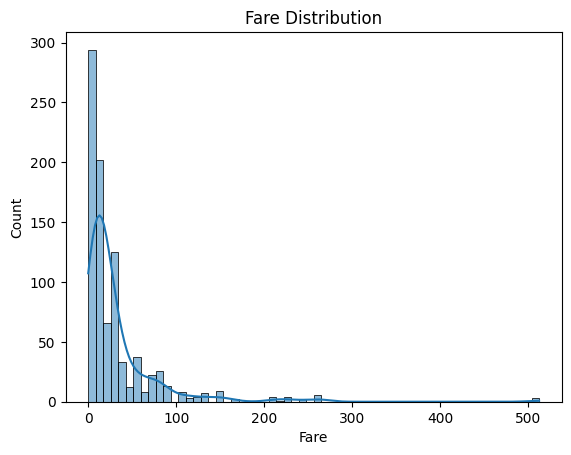

In [11]:
sns.histplot(train_data["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()


In [17]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
def feature_engineering(df):
    df = df.copy()

    # -------- Title from name -------- #
    df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.', expand=False)

    df["Title"] = df["Title"].replace(['Mlle','Ms'],'Miss')
    df["Title"] = df["Title"].replace(['Mme'],'Mrs')

    rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df["Title"] = df["Title"].replace(rare_titles, "Rare")

    # -------- Family size -------- #
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # -------- Cabin Deck -------- #
    df["Cabin"] = df["Cabin"].fillna("Unknown")
    df["Deck"] = df["Cabin"].str[0]

    # -------- Fill Embarked -------- #
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) # Fill missing Embarked with mode beacause it's categorical

    # -------- Fill Fare -------- #
    df["Fare"] = df["Fare"].fillna(df["Fare"].median()) # Fill missing Fare with median because it's numerical

    # -------- Drop columns not used -------- #
    df = df.drop(["Ticket", "Name", "Cabin"], axis=1)

    return df


In [20]:
train_data_modified = feature_engineering(train_data)
test_data_modified = feature_engineering(test_data)

In [21]:
train_data_modified.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,Deck
0,1,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,U
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,C
2,3,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,U
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,C
4,5,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,U


In [22]:
X = train_data_modified.drop("Survived", axis=1)
y = train_data_modified["Survived"]

In [23]:
numeric_cols = ["Age", "Fare", "FamilySize"]
categorical_cols = [col for col in X.columns if col not in numeric_cols]


In [24]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("cat", cat_pipeline, categorical_cols)
    ]
)


In [26]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", model)
])


In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
full_pipeline.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred = full_pipeline.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))


Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179

[[97 13]
 [23 46]]


In [31]:
test_pred = full_pipeline.predict(test_data_modified)


In [33]:
submission = pd.DataFrame({
    "PassengerId": test_data_modified["PassengerId"],
    "Survived": test_pred
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")


submission.csv saved!
